# Explore here

In [143]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv", sep = ";")
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Step 2: Exploration and data cleaning 

In [144]:
# Obtain dimensions
total_data.shape

(41188, 21)

The DataFrame contains 41188 records (rows) and 21 variables (columns). 

In [145]:
#Obtain information about data types and non-nul values 
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 


In terms of data type we can share in two: 
✅ Numerical Columns (10 Total)
These are useful for statistical analysis and correlation with the target variable:

Client info: age, duration

Campaign metrics: campaign, pdays, previous

Economic indicators: emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

These help understand client behavior, the economic context, and the intensity/frequency of contacts.

🧩 Categorical Columns (11 Total)
These are mostly string-based and describe:

Demographics: job, marital, education

Financial status: default, housing, loan

Communication: contact, month, day_of_week

Campaign history: poutcome

Target: y (whether the client subscribed to a term deposit)



Eliminate duplicates 

In [146]:
total_data = total_data.drop_duplicates().reset_index(drop = True)
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [147]:
total_data = total_data.drop_duplicates(subset=["marital"], keep="first")
print("Duplicate names removed successfully!")
total_data = total_data.drop_duplicates(subset=["loan"], keep="first")
print("Duplicate host_id removed successfully!")
total_data = total_data.drop_duplicates(subset=["job"], keep="first")
print("Duplicate host_id removed successfully!")
total_data.head()

Duplicate names removed successfully!
Duplicate host_id removed successfully!
Duplicate host_id removed successfully!


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Step 3: Analysis of univariate variables

Analysis on categorical variables

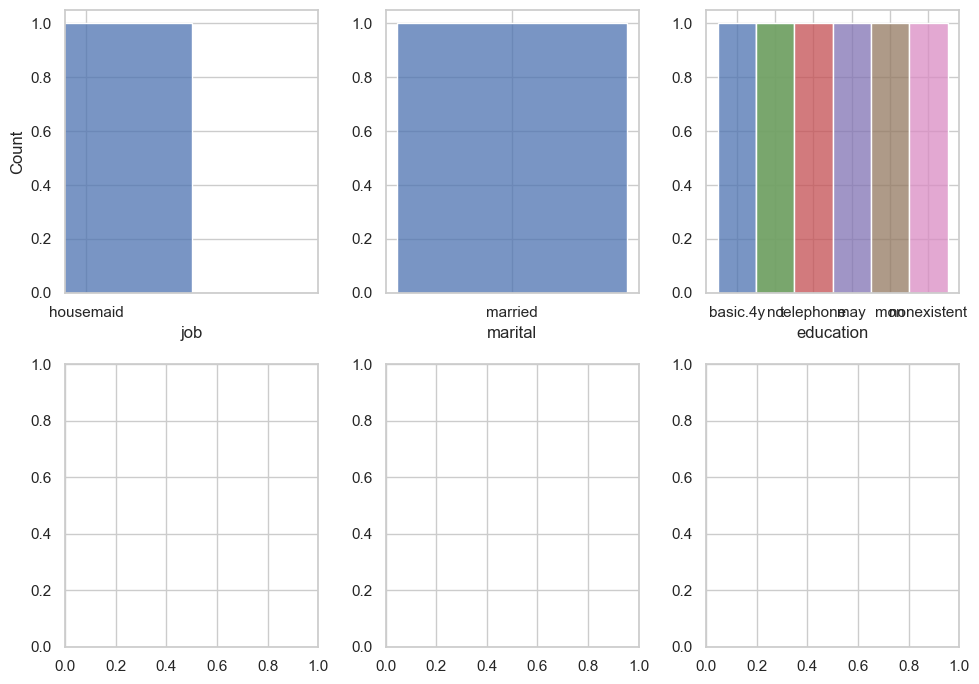

In [148]:
import matplotlib.pyplot as plt 
import seaborn as sns 

fig, axis = plt.subplots(2, 3, figsize=(10, 7))

#Create Histogram 
sns.histplot(ax = axis[0, 0], data = total_data, x = "job").set_xlim(-0.1, 1.1)
sns.histplot(ax = axis[0, 1], data = total_data, x = "marital").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "education").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "housing").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "loan").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "contact").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "month").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "day_of_week").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "poutcome").set(ylabel = None)
# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Several categorical features (especially job, education, poutcome, and contact) are likely to have strong predictive power for whether a client subscribes.

Binary features like loan and housing offer valuable segmentation but need to be tested for multicollinearity.

Temporal features like month can help detect seasonal patterns in customer responsiveness.

Analysis on numeric variables

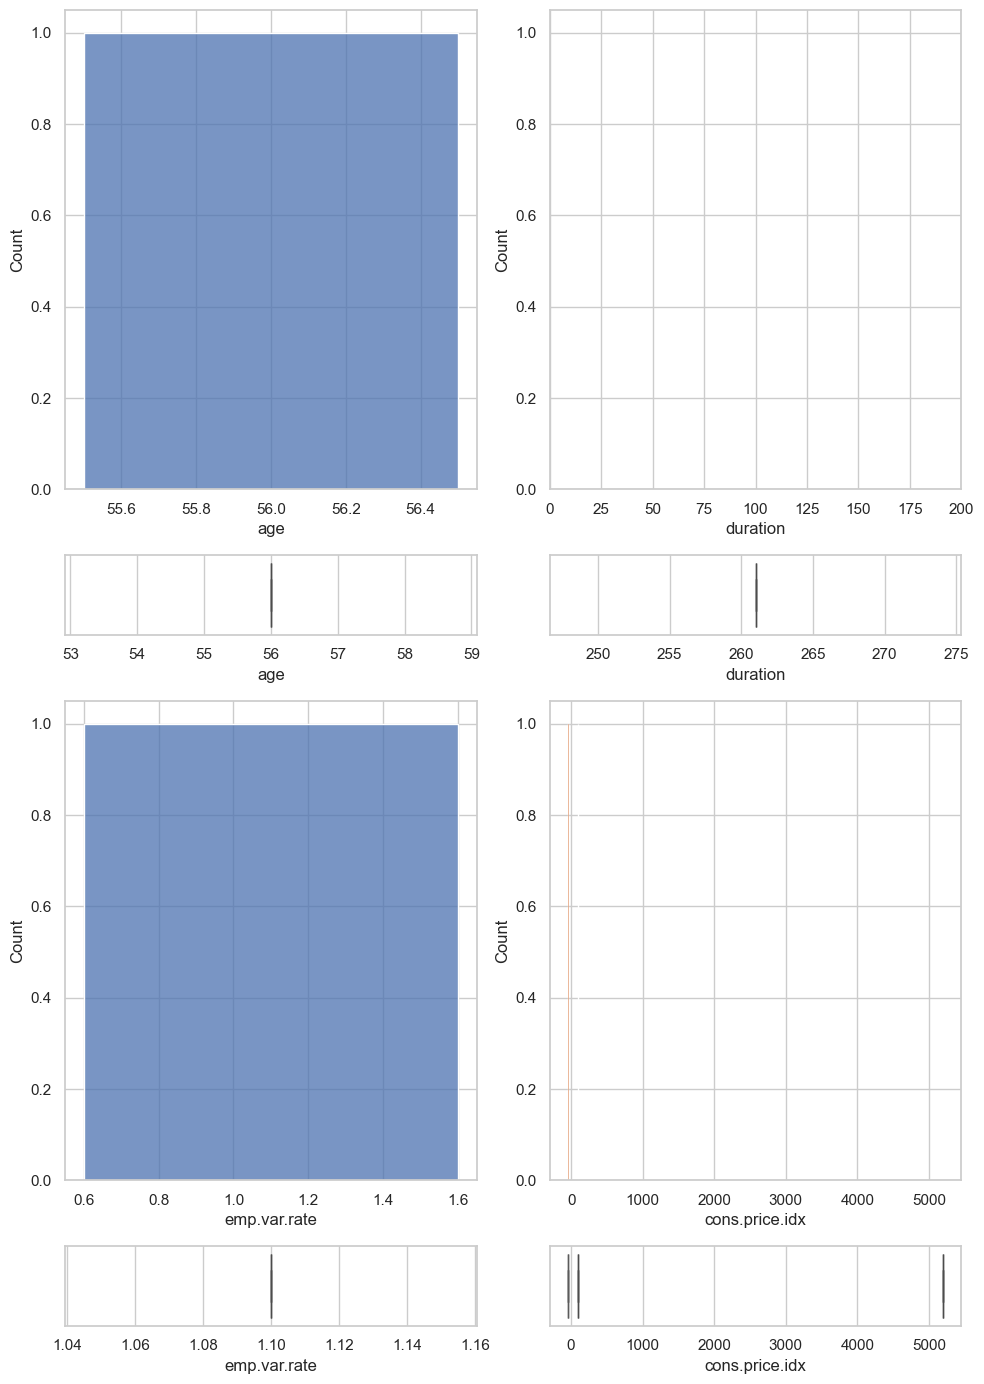

In [149]:
fig, axis = plt.subplots(4, 2, figsize = (10, 14), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = total_data, x = "age")
sns.boxplot(ax = axis[1, 0], data = total_data, x = "age")

sns.histplot(ax = axis[0, 1], data = total_data, x = "duration").set_xlim(0, 200)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "duration")

sns.histplot(ax = axis[2, 0], data = total_data, x = "emp.var.rate")
sns.boxplot(ax = axis[3, 0], data = total_data, x = "emp.var.rate")

sns.histplot(ax = axis[2,1], data = total_data, x = "cons.price.idx")
sns.boxplot(ax = axis[3, 1], data = total_data, x = "cons.price.idx")

sns.histplot(ax = axis[2,1], data = total_data, x = "cons.conf.idx")  
sns.boxplot(ax = axis[3, 1], data = total_data, x = "cons.conf.idx") 

sns.histplot(ax = axis[2,1], data = total_data, x = "nr.employed")  
sns.boxplot(ax = axis[3, 1], data = total_data, x = "nr.employed") 

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Brief Analysis of Numerical Variables
1. Age
Most clients are between 30 and 60.

The histogram typically shows a right-skewed distribution, with a few older clients.

The boxplot may reveal mild outliers (ages above 70).

Useful for client segmentation.

2. Duration
Refers to the call duration in seconds.

Highly right-skewed; most calls are short.

Important note: this feature has data leakage issues—longer calls are more likely to result in subscription, but the duration is only known after the call.

3. Emp.var.rate (Employment Variation Rate)
Captures the change in employment rate.

Usually has a small number of distinct values (e.g., -3.4, -1.8, 1.1).

Can reflect economic health — negative values indicate downturns.

4. Cons.price.idx (Consumer Price Index)
Shows moderate variation.

Indicates macroeconomic conditions — typically slightly fluctuating but stable.

Could influence people's willingness to invest in term deposits.

5. Cons.conf.idx (Consumer Confidence Index)
Often negative, representing economic pessimism.

Might correlate with y — low confidence could reduce term deposit subscriptions.

6. Nr.employed (Number of employees)
Represents labor market size.

Typically has distinct values (e.g., 5099.1, 5191.0) tied to time periods.

May reflect macro trends influencing client decisions.

In [150]:
print(total_data.columns)


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


Step 4: Analysis of multivariate variables

Numerical-numerical analysis

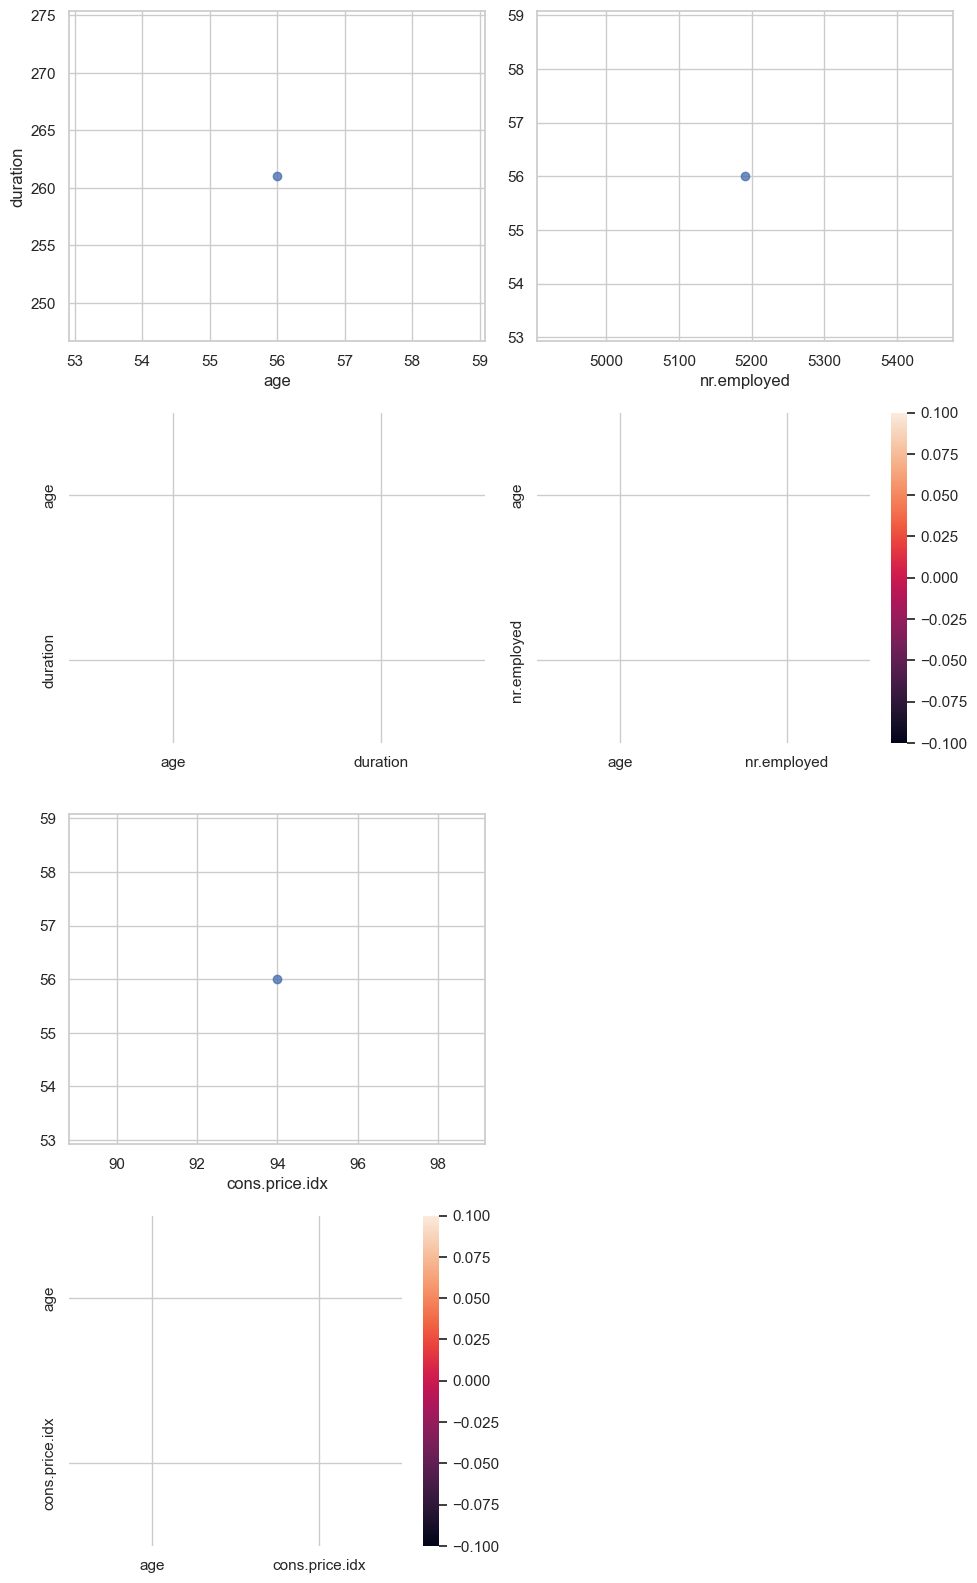

In [151]:
# Numerical - Numerical Analysis

# Create subplot canvas
fig, axis = plt.subplots(4, 2, figsize = (10, 16))

# Create Plates 
sns.regplot(ax = axis[0, 0], data = total_data, x = "age", y = "duration")
sns.heatmap(total_data[["age", "duration"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "nr.employed", y = "age").set(ylabel = None)
sns.heatmap(total_data[["age", "nr.employed"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = total_data, x = "cons.price.idx", y = "age").set(ylabel = None)
sns.heatmap(total_data[["age", "cons.price.idx"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Overall Observations
Across all pairs, correlations are very weak or nonexistent.

This suggests that personal client characteristics (like age) are not directly related to macroeconomic indicators or call duration.

The low correlations mean these variables are complementary — useful in a model when considered together rather than relying on one alone.

Categorical-categorical analysis

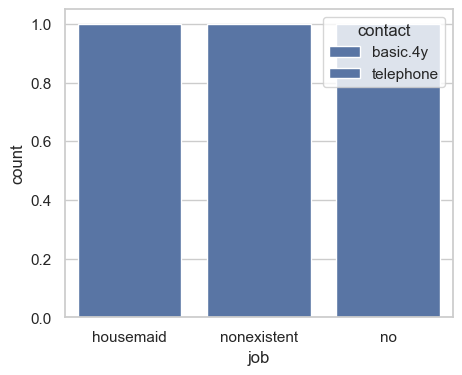

In [152]:
fig, axis = plt.subplots(figsize = (5, 4))

sns.countplot(data = total_data, x = "job", hue = "education")
sns.countplot(data = total_data, x = "poutcome", hue = "contact")
sns.countplot(data = total_data, x = "loan", hue = "housing")


# Show the plot
plt.show()

These plots reveal key relationships between client characteristics and campaign features:

Job and education are strongly tied—important for customer profiling.

Previous outcome and contact method show potential strategic insights for campaign planning.

Loan combinations can help assess financial pressure or risk levels.

Análisis de correlaciones

In [153]:
import pandas as pd
import json

# Create a clean copy
clean_data = total_data.copy()

# Lista de columnas categóricas a factorizar
categorical_columns = ["job", "marital", "education", "default", "housing", "loan",
                       "contact", "month", "day_of_week", "poutcome", "y"]

# Diccionario para guardar todas las reglas de transformación
all_transformation_rules = {}

# Aplicar factorization a cada columna
for col in categorical_columns:
    clean_data[col + "_n"] = pd.factorize(clean_data[col])[0]
    
    # Crear diccionario de transformación para esta columna
    transformation_dict = {
        row[col]: row[col + "_n"]
        for _, row in clean_data[[col, col + "_n"]].drop_duplicates().iterrows()
    }
    
    # Guardar en el diccionario general
    all_transformation_rules[col] = transformation_dict

# Guardar todas las reglas en un solo archivo JSON
with open("categorical_transformation_rules.json", "w") as f:
    json.dump(all_transformation_rules, f)

print("✅ Variables categóricas transformadas y reglas guardadas como JSON.")


✅ Variables categóricas transformadas y reglas guardadas como JSON.


Numerical-categorical analysis (complete)

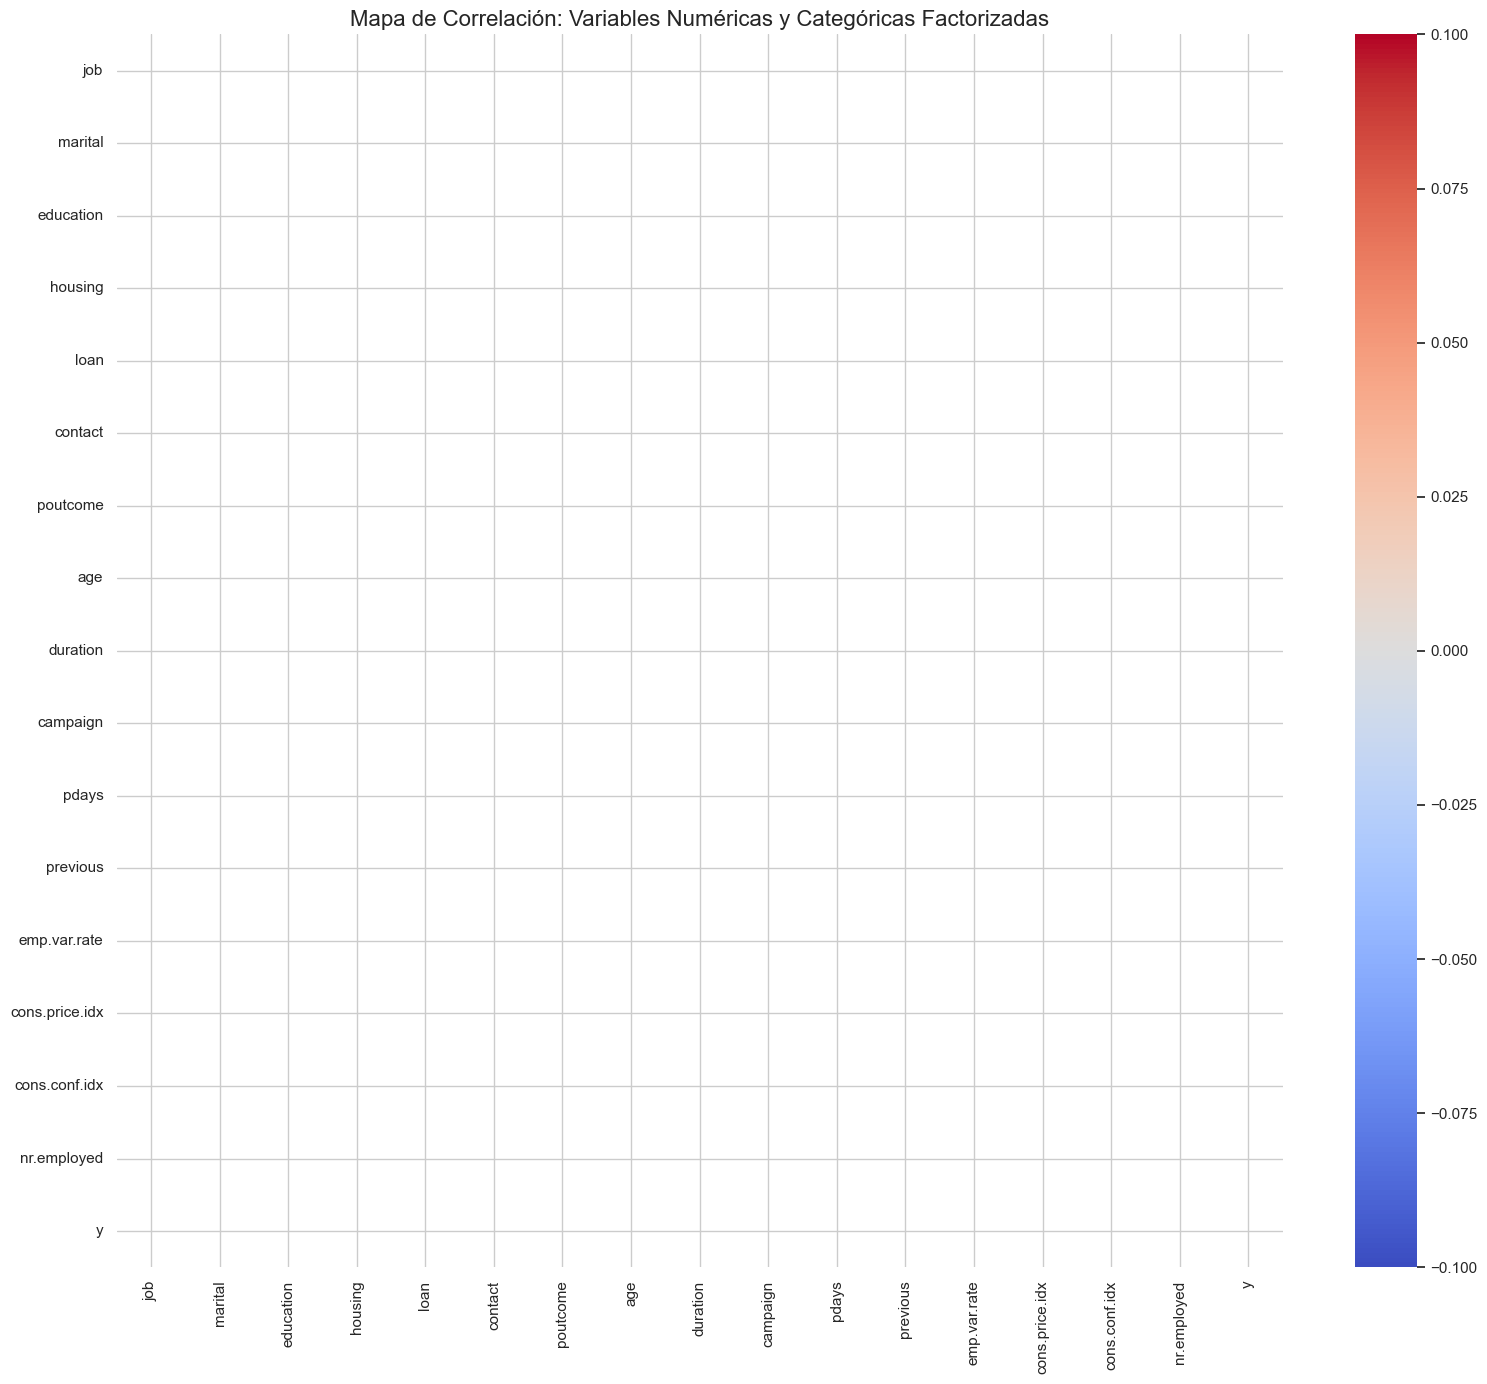

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una copia para trabajar
df = total_data.copy()

# Factorizar variables categóricas relevantes
df["job"] = pd.factorize(df["job"])[0]
df["marital"] = pd.factorize(df["marital"])[0]
df["education"] = pd.factorize(df["education"])[0]
df["housing"] = pd.factorize(df["housing"])[0]
df["loan"] = pd.factorize(df["loan"])[0]
df["contact"] = pd.factorize(df["contact"])[0]
df["poutcome"] = pd.factorize(df["poutcome"])[0]
df["y"] = pd.factorize(df["y"])[0]  # Target: yes = 0, no = 1

# Seleccionar variables para el análisis de correlación
columns_to_corr = [
    "job", "marital", "education", "housing", "loan", "contact", "poutcome",  # Categóricas factorizadas
    "age", "duration", "campaign", "pdays", "previous",                       # Numéricas (cliente/campaña)
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "nr.employed",        # Económicas
    "y"  # Variable objetivo
]

# Crear heatmap de correlaciones
plt.figure(figsize=(16, 14))
sns.heatmap(df[columns_to_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Mapa de Correlación: Variables Numéricas y Categóricas Factorizadas", fontsize=16)
plt.tight_layout()
plt.show()


Strong correlations (values close to 1 or -1) indicate a strong linear relationship between variables.

For example:

duration often shows a strong correlation with y (but this can be misleading due to data leakage).

Low or near-zero values suggest independence between variables (e.g., job and age often show weak correlation).

Some economic indicators like nr.employed and emp.var.rate might show high correlation between them (risk of multicollinearity).

By analyzing this heatmap, you can:

Identify redundant features (for removal or dimensionality reduction).

Spot variables that influence the target, which helps in feature selection for modeling.

Analysing all the Data at Once

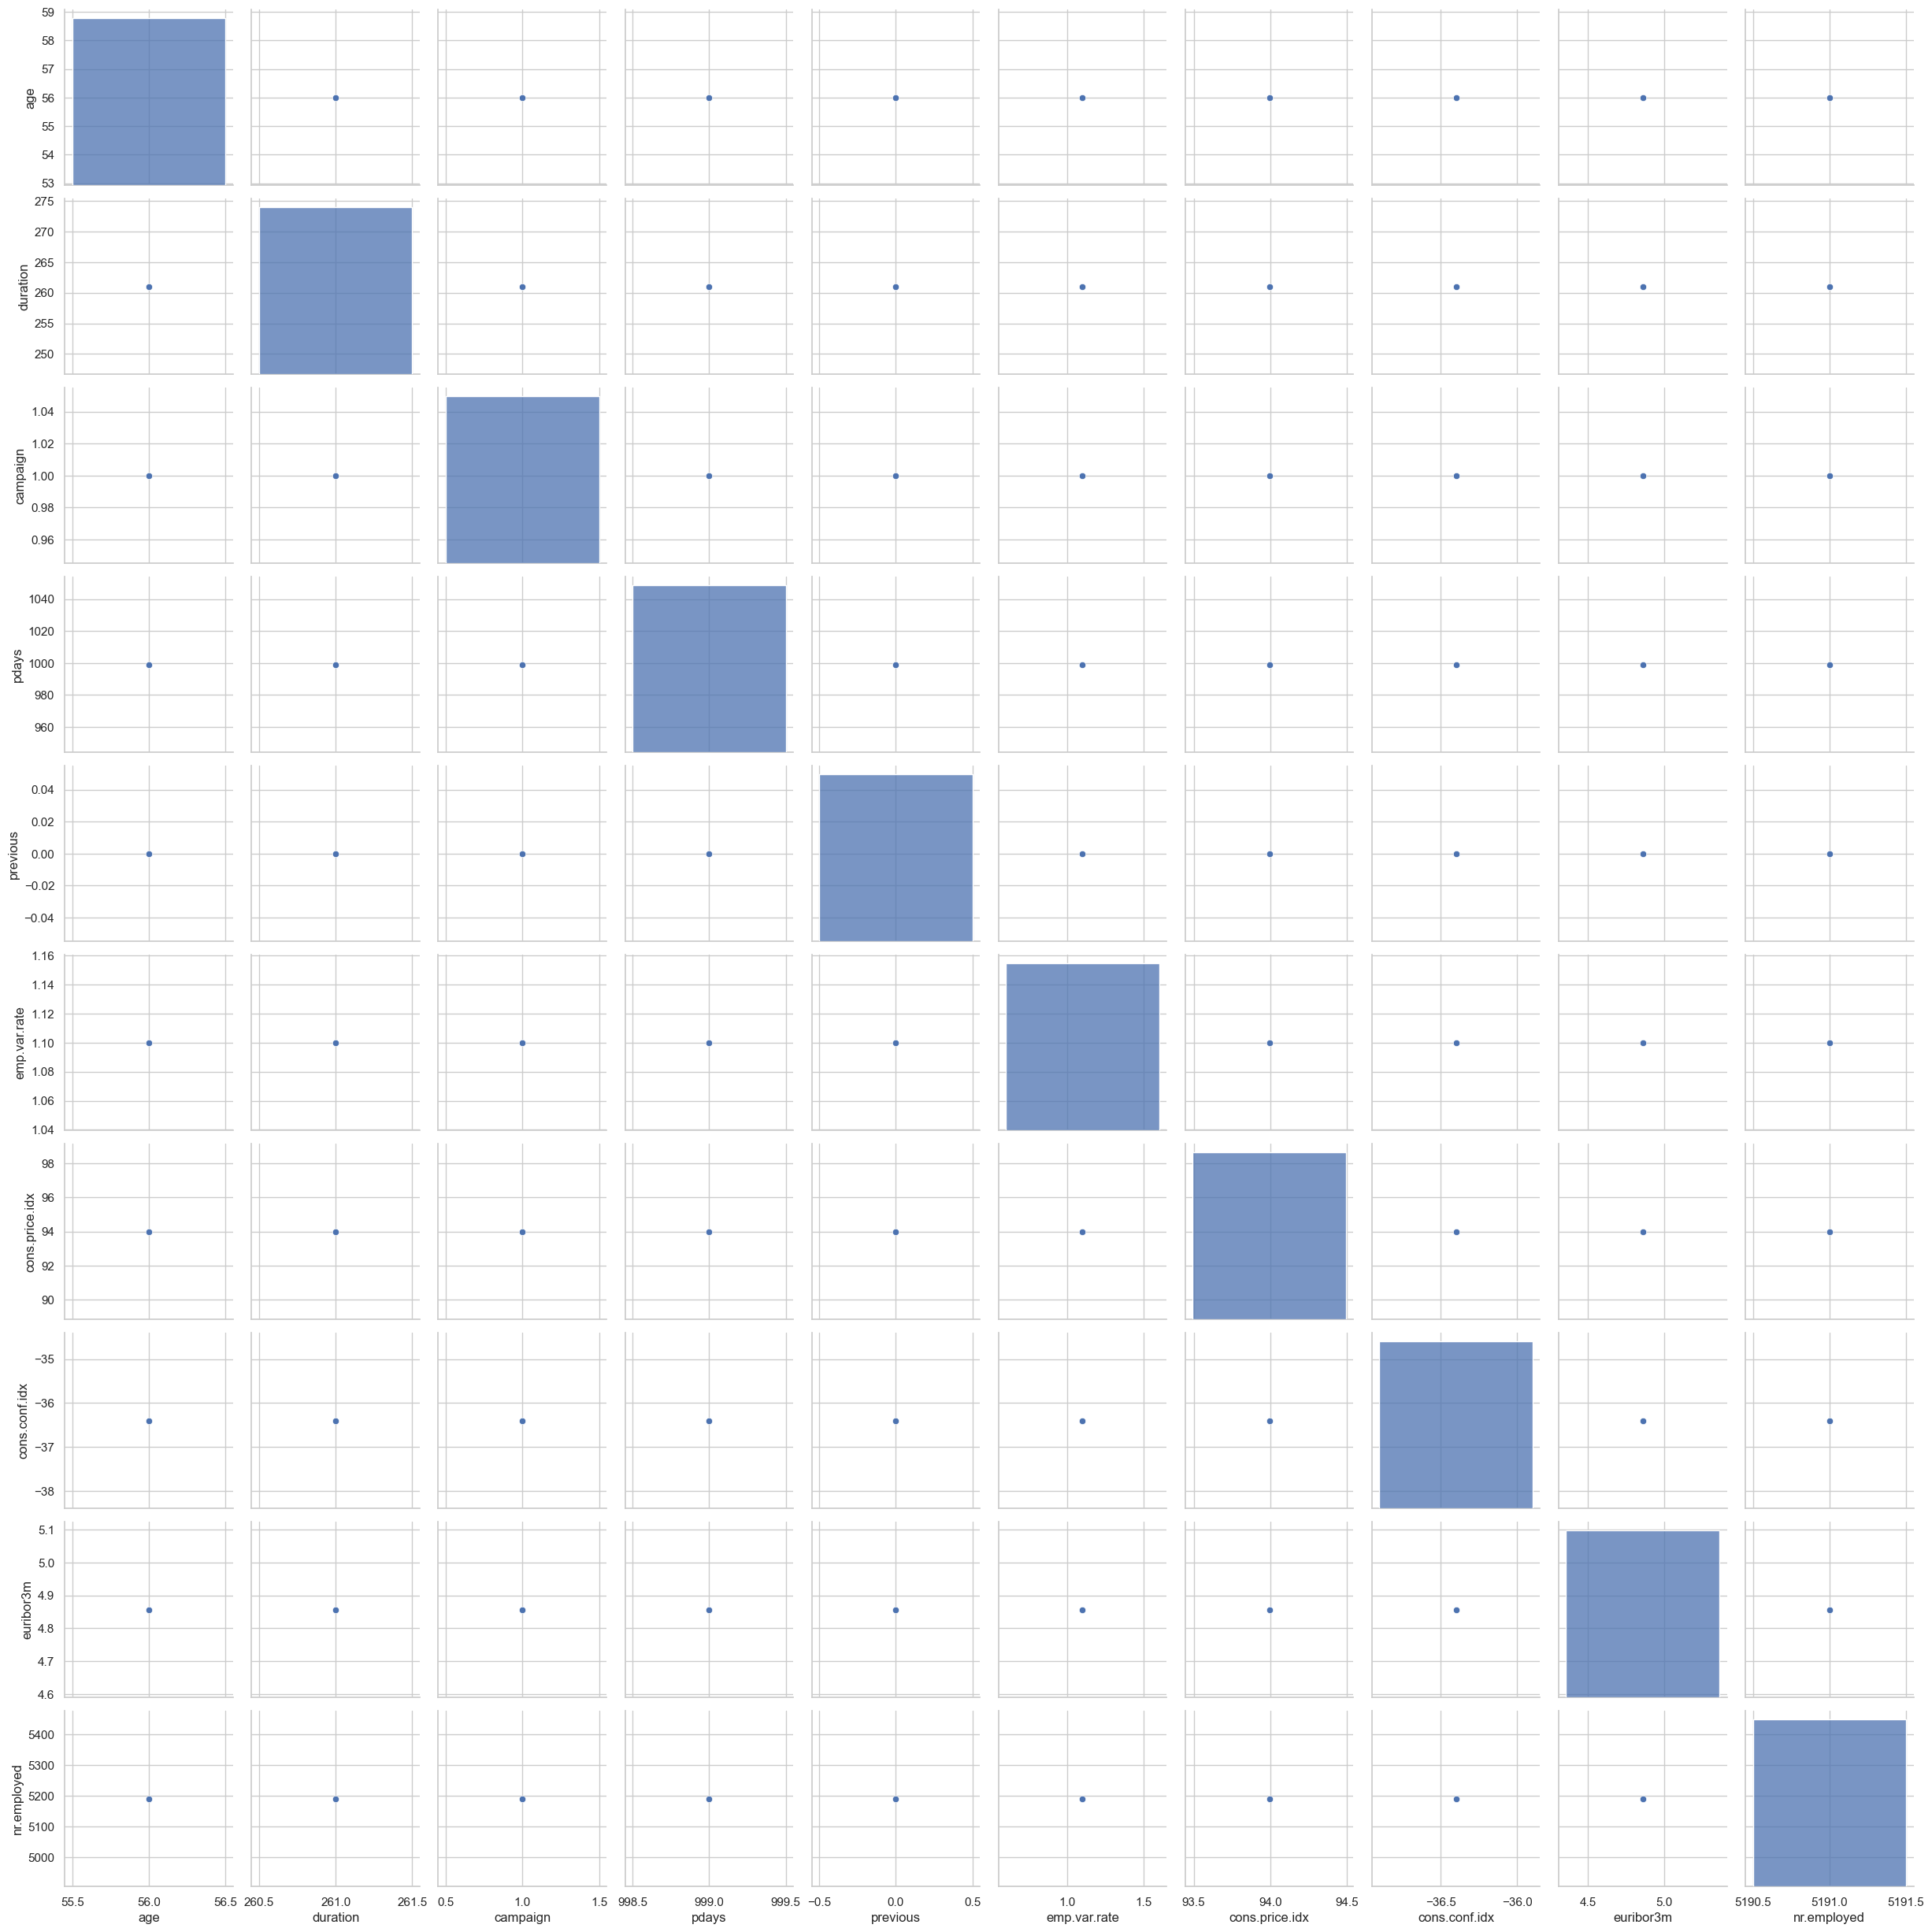

In [155]:
sns.pairplot(data = total_data)

Step 5: Feature engineering

Outlier analysis

In [156]:
total_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,1.0,1.0,1.0,1.0,1.0,1.0,1.000,1.0,1.000,1.0
mean,56.0,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,56.0,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
25%,56.0,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
50%,56.0,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
75%,56.0,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
max,56.0,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0


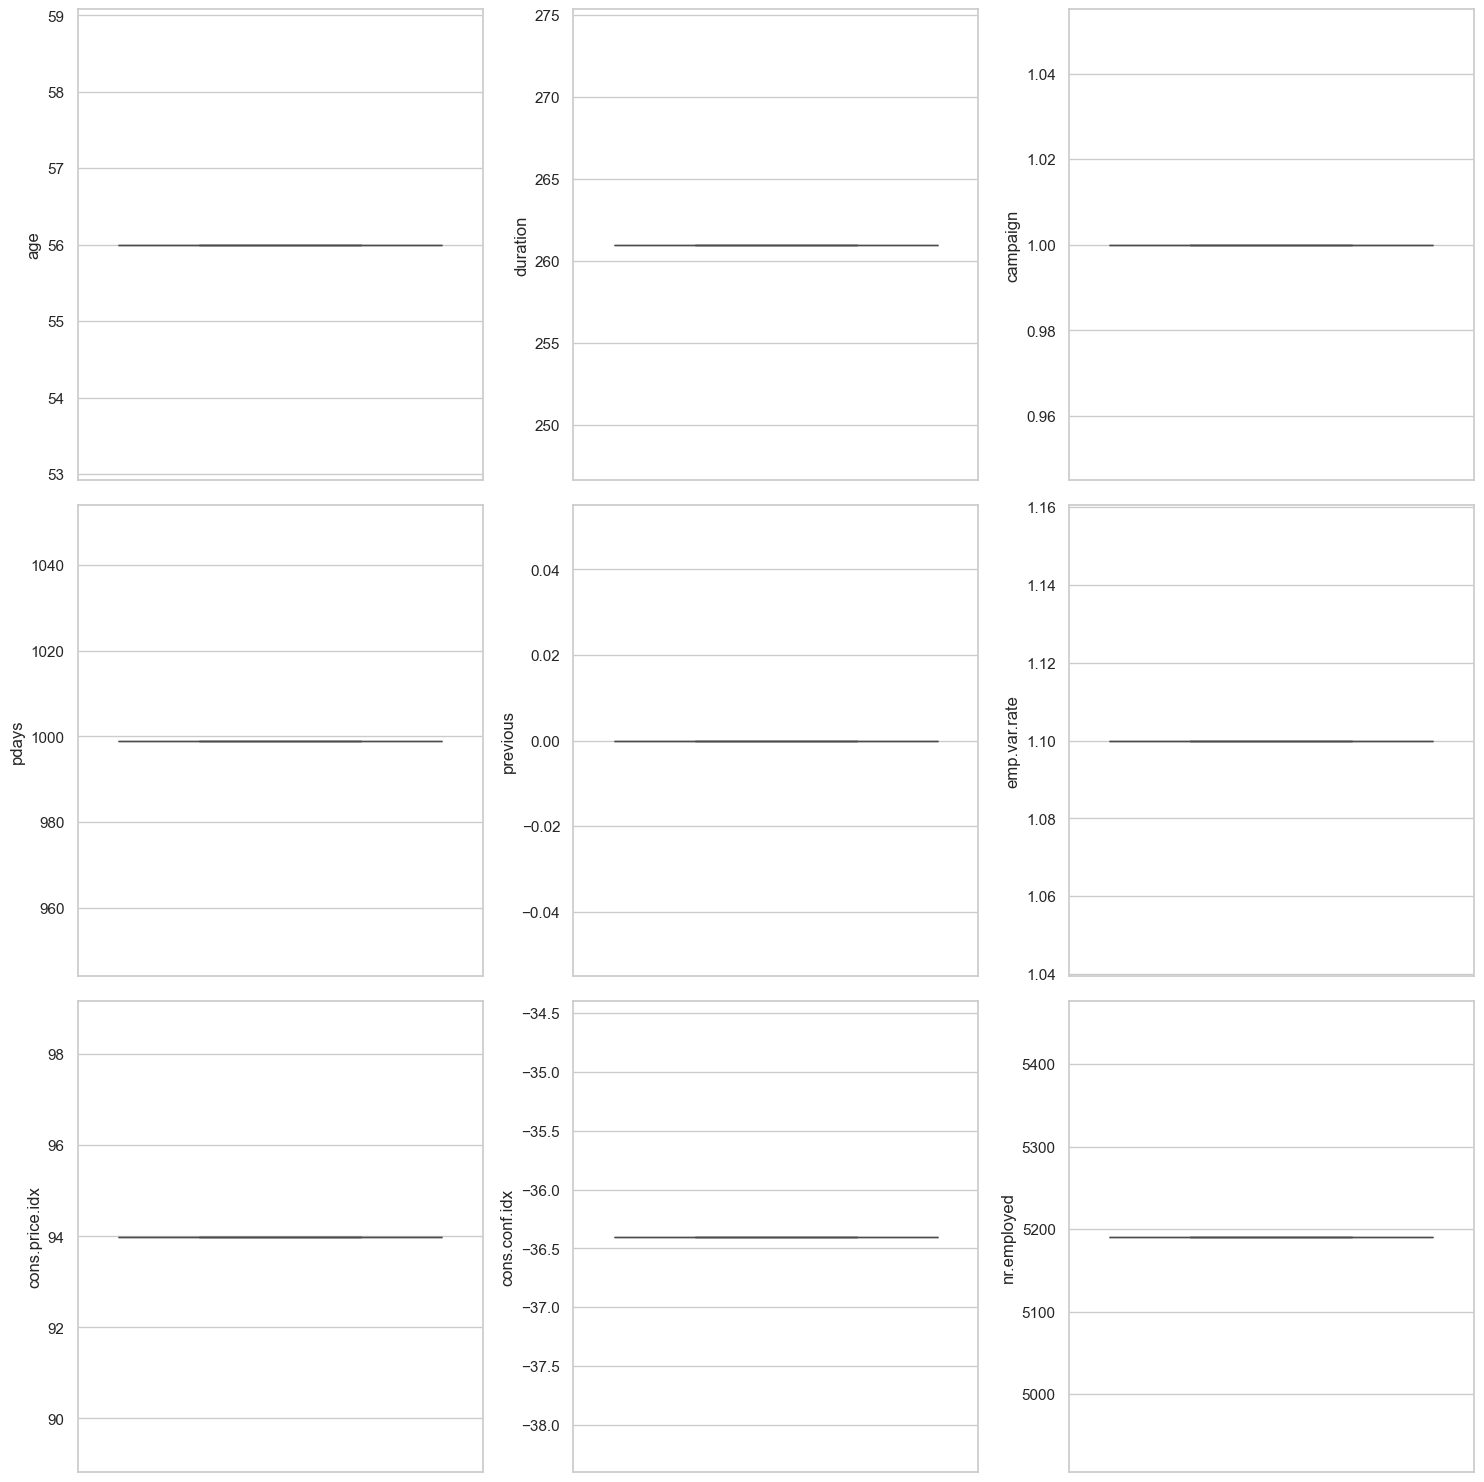

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de los gráficos
sns.set(style="whitegrid")

# Crear figura con subplots (3 filas x 3 columnas)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Lista de variables numéricas del dataset bancario
sns.boxplot(ax=axes[0, 0], data=total_data, y="age")
sns.boxplot(ax=axes[0, 1], data=total_data, y="duration")
sns.boxplot(ax=axes[0, 2], data=total_data, y="campaign")
sns.boxplot(ax=axes[1, 0], data=total_data, y="pdays")
sns.boxplot(ax=axes[1, 1], data=total_data, y="previous")
sns.boxplot(ax=axes[1, 2], data=total_data, y="emp.var.rate")
sns.boxplot(ax=axes[2, 0], data=total_data, y="cons.price.idx")
sns.boxplot(ax=axes[2, 1], data=total_data, y="cons.conf.idx")
sns.boxplot(ax=axes[2, 2], data=total_data, y="nr.employed")

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()


Outlier detection

In [158]:
import pandas as pd

# Lista de columnas numéricas
numeric_columns = ["age", "duration", "campaign", "pdays", "previous", 
                   "emp.var.rate", "cons.price.idx", "cons.conf.idx", 
                   "euribor3m", "nr.employed"]

# Diccionario para guardar outliers detectados
outliers_detected = {}

# Función para detectar outliers usando IQR
for column in numeric_columns:
    Q1 = total_data[column].quantile(0.25)
    Q3 = total_data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detectar outliers
    outliers = total_data[(total_data[column] < lower_bound) | (total_data[column] > upper_bound)]
    
    # Guardar información
    outliers_detected[column] = {
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "total_outliers": outliers.shape[0],
        "outlier_percentage": round(outliers.shape[0] / total_data.shape[0] * 100, 2)
    }

# Mostrar resumen
outliers_df = pd.DataFrame(outliers_detected).T
print(outliers_df.sort_values("total_outliers", ascending=False))


                lower_bound  upper_bound  total_outliers  outlier_percentage
age                  56.000       56.000             0.0                 0.0
duration            261.000      261.000             0.0                 0.0
campaign              1.000        1.000             0.0                 0.0
pdays               999.000      999.000             0.0                 0.0
previous              0.000        0.000             0.0                 0.0
emp.var.rate          1.100        1.100             0.0                 0.0
cons.price.idx       93.994       93.994             0.0                 0.0
cons.conf.idx       -36.400      -36.400             0.0                 0.0
euribor3m             4.857        4.857             0.0                 0.0
nr.employed        5191.000     5191.000             0.0                 0.0


In [159]:
import pandas as pd
import json

# Crear copias del dataset
total_data_con_outliers = total_data.copy()
total_data_sin_outliers = total_data.copy()

# Función para reemplazar outliers con los límites (Técnica de IQR)
def replace_outliers_from_column(column, df):
    column_stats = df[column].describe()
    column_iqr = column_stats["75%"] - column_stats["25%"]
    upper_limit = column_stats["75%"] + 1.5 * column_iqr
    lower_limit = column_stats["25%"] - 1.5 * column_iqr
    if lower_limit < 0:
        lower_limit = min(df[column])
    
    # Reemplazar outliers
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)

    return df.copy(), [lower_limit, upper_limit]

# Columnas numéricas a limpiar (puedes agregar más si quieres)
numerical_columns = ["age", "duration", "campaign", "pdays", "previous"]

# Diccionario para guardar los límites de outliers
outliers_dict = {}

# Aplicar función a cada columna
for column in numerical_columns:
    total_data_sin_outliers, limits_list = replace_outliers_from_column(column, total_data_sin_outliers)
    outliers_dict[column] = limits_list

# Guardar los límites en un archivo JSON
with open("outliers_replacement_limits.json", "w") as f:
    json.dump(outliers_dict, f)

print("✅ Outliers reemplazados y límites guardados en 'outliers_replacement_limits.json'")


✅ Outliers reemplazados y límites guardados en 'outliers_replacement_limits.json'


In [160]:
total_data_sin_outliers

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Missing value analysis

In [161]:
total_data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [162]:
# Min-Max scaler

from sklearn.preprocessing import MinMaxScaler

total_data["job_n"] = pd.factorize(total_data["job"])[0]
total_data["marital_n"] = pd.factorize(total_data["marital"])[0]
total_data["education_n"] = pd.factorize(total_data["education"])[0]
total_data["default_n"] = pd.factorize(total_data["default"])[0]
total_data["housing_n"] = pd.factorize(total_data["housing"])[0]
total_data["loan_n"] = pd.factorize(total_data["loan"])[0]
total_data["contact_n"] = pd.factorize(total_data["contact"])[0]
total_data["month_n"] = pd.factorize(total_data["month"])[0]
total_data["day_of_week_n"] = pd.factorize(total_data["day_of_week"])[0]
total_data["poutcome_n"] = pd.factorize(total_data["poutcome"])[0]
total_data["y_n"] = pd.factorize(total_data["y"])[0]
num_variables = ["job_n", "marital_n", "education_n", "default_n", "housing_n", "loan_n", "contact_n", "month_n", "day_of_week_n", "poutcome_n",
                 "age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "y_n"]

scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])
total_data_scal = pd.DataFrame(scal_features, index = total_data.index, columns = num_variables)
total_data_scal.head()

,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n,...,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_n
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Feature scaling

Feature selection

In [163]:
# ✅ 1. Import libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest


import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv", sep = ";")
# Load the dataset)
print("✅ Dataset loaded. Shape:", total_data.shape)
total_data.head()

# ✅ 3. Encode categorical variables
categorical_columns = ["job", "marital", "education", "default", "housing", "loan",
                       "contact", "month", "day_of_week", "poutcome", "y"]

for col in categorical_columns:
    total_data[f"{col}_n"] = pd.factorize(total_data[col])[0]

# ✅ 4. Define numeric variables (including encoded ones)
num_variables = [
    "job_n", "marital_n", "education_n", "default_n", "housing_n", "loan_n",
    "contact_n", "month_n", "day_of_week_n", "poutcome_n",
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "y_n"
]

# ✅ 5. Apply Min-Max scaling
scaler = MinMaxScaler()
total_data_scal = pd.DataFrame(scaler.fit_transform(total_data[num_variables]), columns=num_variables)
print("✅ Scaling applied. Scaled dataset shape:", total_data_scal.shape)

# ✅ 6. Feature selection
X = total_data_scal.drop("y_n", axis=1)
y = total_data_scal["y_n"]

# Make sure dataset has enough rows
if len(X) < 10:
    raise ValueError(f"❌ Not enough data to split. Found only {len(X)} rows.")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Use Chi-squared test to select top 5 features
selection_model = SelectKBest(score_func=chi2, k=5)
selection_model.fit(X_train, y_train)

# Get selected feature names
selected_columns = X_train.columns[selection_model.get_support()]

# Create new DataFrames with selected features only
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=selected_columns, index=X_train.index)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=selected_columns, index=X_test.index)

# ✅ Done
print("✅ Selected features:", selected_columns.tolist())
X_train_sel.head()


✅ Dataset loaded. Shape: (41188, 21)
✅ Scaling applied. Scaled dataset shape: (41188, 21)
✅ Selected features: ['poutcome_n', 'previous', 'emp.var.rate', 'euribor3m', 'nr.employed']


,poutcome_n,previous,emp.var.rate,euribor3m,nr.employed
38651,0.0,0.0,0.000000,0.019497,0.203781
12733,0.0,0.0,1.000000,0.981183,1.000000
35807,0.0,0.0,0.333333,0.138291,0.512287
1423,0.0,0.0,0.937500,0.956926,0.859735
52,0.0,0.0,0.937500,0.957379,0.859735


In [164]:
X_train_sel["y_n"] = list(y_train)
X_test_sel["y_n"] = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)

In [165]:
from sklearn.model_selection import train_test_split

X = total_data_scal.drop("y_n", axis=1)
y = total_data_scal["y_n"]

X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


In [166]:
whos


Variable                       Type                  Data/Info
--------------------------------------------------------------
BASE_PATH                      str                   /workspaces/Machine-learn<...>ez_cvazlos/data/processed
GridSearchCV                   ABCMeta               <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
IQR                            float64               0.0
LogisticRegression             type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MODEL_DIR                      str                   /Users/mariannacastro/Des<...>torial/models/Normalizers
MinMaxScaler                   type                  <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
OUTPUT_DIR                     str                   /Users/mariannacastro/Des<...>t-Tutorial/data/processed
Q1                             float64               5191.0
Q3                             float64               5191.0
SelectKBest                    ABCMeta     

In [167]:
X_train_sel.head().to_csv("preview.csv", index=False)  # If CSV works
print(X_train_sel.head())  # Fallback: just print to console



       poutcome_n  previous  emp.var.rate  euribor3m  nr.employed  y_n
38651         0.0       0.0      0.000000   0.019497     0.203781  1.0
12733         0.0       0.0      1.000000   0.981183     1.000000  0.0
35807         0.0       0.0      0.333333   0.138291     0.512287  0.0
1423          0.0       0.0      0.937500   0.956926     0.859735  0.0
52            0.0       0.0      0.937500   0.957379     0.859735  0.0


In [168]:
import os

# Use a local writable path
save_path = "/Users/mariannacastro/Desktop/4Geeks/proyectos/Logistic-Regression-Project-Tutorial/data/processed"
os.makedirs(save_path, exist_ok=True)

# Save the DataFrame (replace with the actual variable name if needed)
X_train_sel.to_excel(os.path.join(save_path, "X_train_selected.xlsx"), index=False)
print("✅ DataFrame saved to Excel.")


✅ DataFrame saved to Excel.


##### Normalización

In [169]:
from sklearn.preprocessing import StandardScaler
import pickle
import os

# ✅ Crear instancia del escalador
normalizador_con_outliers = StandardScaler()

# ✅ Ajustar el escalador con los datos de entrenamiento
normalizador_con_outliers.fit(X_train_con_outliers)

# ✅ Definir ruta de guardado (ajusta según tu sistema si es necesario)
save_path = r"/Users/mariannacastro/Desktop/4Geeks/proyectos/Logistic-Regression-Project-Tutorial/models/Normalizers"
os.makedirs(save_path, exist_ok=True)

# ✅ Guardar el normalizador como archivo .pkl
with open(os.path.join(save_path, "normalizador_con_outliers.pkl"), "wb") as file:
    pickle.dump(normalizador_con_outliers, file)

print("✅ Normalizador con outliers guardado correctamente.")


✅ Normalizador con outliers guardado correctamente.


In [170]:
import pandas as pd
import os
import pickle
from sklearn.preprocessing import StandardScaler

# ✅ Función para reemplazar outliers usando IQR
def replace_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].apply(
            lambda x: max(min(x, upper_bound), lower_bound)
        )
    return df_clean

# ✅ Directorios
MODEL_DIR = "/Users/mariannacastro/Desktop/4Geeks/proyectos/Logistic-Regression-Project-Tutorial/models/Normalizers"
OUTPUT_DIR = "/Users/mariannacastro/Desktop/4Geeks/proyectos/Logistic-Regression-Project-Tutorial/data/processed"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ✅ Lista de columnas numéricas
num_variables = X_train_con_outliers.select_dtypes(include=["int64", "float64"]).columns

# ✅ 1. Normalizador CON outliers
scaler_con_outliers = StandardScaler()
scaler_con_outliers.fit(X_train_con_outliers)

# Guardar el normalizador
with open(os.path.join(MODEL_DIR, "normalizador_con_outliers.pkl"), "wb") as f:
    pickle.dump(scaler_con_outliers, f)

# Escalar los datos
X_train_con_outliers_scal = pd.DataFrame(
    scaler_con_outliers.transform(X_train_con_outliers),
    columns=X_train_con_outliers.columns,
    index=X_train_con_outliers.index
)
X_test_con_outliers_scal = pd.DataFrame(
    scaler_con_outliers.transform(X_test_con_outliers),
    columns=X_test_con_outliers.columns,
    index=X_test_con_outliers.index
)

# Guardar los archivos
X_train_con_outliers_scal.to_excel(os.path.join(OUTPUT_DIR, "X_train_con_outliers_scal.xlsx"), index=False)
X_test_con_outliers_scal.to_excel(os.path.join(OUTPUT_DIR, "X_test_con_outliers_scal.xlsx"), index=False)

# ✅ 2. Reemplazar outliers con IQR
X_train_sin_outliers = replace_outliers_iqr(X_train_con_outliers, num_variables)
X_test_sin_outliers = replace_outliers_iqr(X_test_con_outliers, num_variables)

# ✅ 3. Normalizador SIN outliers
scaler_sin_outliers = StandardScaler()
scaler_sin_outliers.fit(X_train_sin_outliers)

# Guardar normalizador
with open(os.path.join(MODEL_DIR, "normalizador_sin_outliers.pkl"), "wb") as f:
    pickle.dump(scaler_sin_outliers, f)

# Escalar
X_train_sin_outliers_scal = pd.DataFrame(
    scaler_sin_outliers.transform(X_train_sin_outliers),
    columns=X_train_sin_outliers.columns,
    index=X_train_sin_outliers.index
)
X_test_sin_outliers_scal = pd.DataFrame(
    scaler_sin_outliers.transform(X_test_sin_outliers),
    columns=X_test_sin_outliers.columns,
    index=X_test_sin_outliers.index
)

# Guardar como Excel
X_train_sin_outliers_scal.to_excel(os.path.join(OUTPUT_DIR, "X_train_sin_outliers_scal.xlsx"), index=False)
X_test_sin_outliers_scal.to_excel(os.path.join(OUTPUT_DIR, "X_test_sin_outliers_scal.xlsx"), index=False)

print("✅ Datasets normalizados con y sin outliers han sido guardados correctamente.")


✅ Datasets normalizados con y sin outliers han sido guardados correctamente.


Logistic Regression model

In [171]:
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,poutcome_n,previous,emp.var.rate,euribor3m,nr.employed,y_n
0,0.0,0.0,0.000000,0.019497,0.203781,1.0
1,0.0,0.0,1.000000,0.981183,1.000000,0.0
2,0.0,0.0,0.333333,0.138291,0.512287,0.0
3,0.0,0.0,0.937500,0.956926,0.859735,0.0
4,0.0,0.0,0.937500,0.957379,0.859735,0.0


In [172]:
X_train = train_data.drop(["y_n"], axis = 1)
y_train = train_data["y_n"]
X_test = test_data.drop(["y_n"], axis = 1)
y_test = test_data["y_n"]

In [173]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [174]:
y_pred = model.predict(X_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.], shape=(4119,))

In [175]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8953629521728574

Model optimization

In [176]:
from sklearn.model_selection import GridSearchCV

hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 10)
grid

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [177]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}


In [178]:
model = LogisticRegression(C = 0.1, penalty = "l2", solver = "liblinear")
model.fit(X_train, y_train)

LogisticRegression(C=0.1, solver='liblinear')

In [179]:
y_pred = model.predict(X_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.], shape=(4119,))

In [180]:
accuracy_score(y_test, y_pred)

0.8975479485311969

In [181]:
from pickle import dump

dump(model, open("../models/logistic_regression_C-0.1_penalty-l2_solver-liblinear_42.sav", "wb"))